🚀 Starting Cavity Decay (Kappa) Sweep...
--- Optimizing Step 1/15: kappa = 0.00 ---
    Resulting Fidelity: 0.7385
--- Optimizing Step 2/15: kappa = 1.25 ---
    Resulting Fidelity: 0.6231
--- Optimizing Step 3/15: kappa = 2.50 ---
    Resulting Fidelity: 0.5605
--- Optimizing Step 4/15: kappa = 3.75 ---
    Resulting Fidelity: 0.5257
--- Optimizing Step 5/15: kappa = 5.00 ---
    Resulting Fidelity: 0.5093
✅ Sweep Complete! Generating graph...


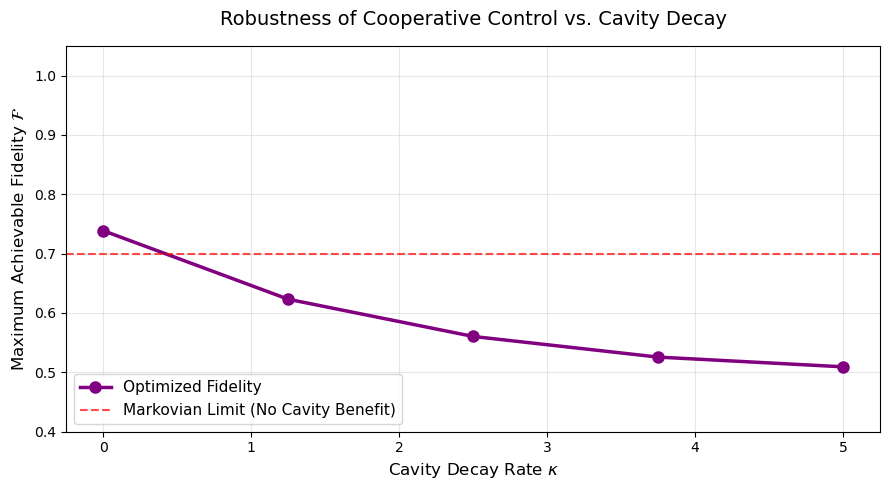

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import qutip_qoc as qoc
from qutip import liouvillian

# 1. Define the sweep array (10 points to save time for now!)
# We sweep kappa from 0.0 (perfect cavity) to 1.0 (very leaky cavity)
     
Ncav = 3
g_int = 0.4 * (2 * np.pi)
gamma = 2.0
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))
H_drift = g_int * (sm * a.dag() + sm.dag() * a) 
H_c = tensor(sigmay(), qeye(N_cav))  

kappa_sweeps = np.linspace(0.0, 5.0, 5)
best_fidelities = []
@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3
guess_params = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
]

bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3


print("🚀 Starting Cavity Decay (Kappa) Sweep...")

current_guess = guess_params
# 2. The Sweep Loop
for i, kappa_val in enumerate(kappa_sweeps):
    print(f"--- Optimizing Step {i+1}/15: kappa = {kappa_val:.2f} ---")
    
    # Rebuild the collapse operators with the new kappa_val
    # (Assuming gamma, sm, and a are already defined in your code above)
    c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa_val) * a]
    
    # Rebuild the Liouvillians so the optimizer "sees" the new noise
    L_drift = liouvillian(H_drift, c_ops_list)
    L_c = liouvillian(H_c) 
    
    # Rebuild the model
    H_model = [L_drift, [L_c, multi_gaussian_jax]]
    
    # Run JOPT
    result = qoc.optimize_pulses(
        objectives=qoc.Objective(rho0, H_model, rho_targ),
        control_parameters={
            "pulse_Y": {
                "guess": current_guess,
                "bounds": bounds,
            }
        },
        tlist=times,
        algorithm_kwargs={
            "alg": "JOPT",
            "fid_err_targ": 1e-3, 
            "max_iter": 500, # Kept slightly lower to speed up the sweep
        }
    )
    
    # Extract fidelity and save it
    fidelity = 1.0 - result.fid_err
    best_fidelities.append(fidelity)
    new_params = result.optimized_params[0]
    current_guess = new_params
    print(f"    Resulting Fidelity: {fidelity:.4f}")

print("✅ Sweep Complete! Generating graph...")

# 3. Plotting the Results
plt.figure(figsize=(9, 5))
plt.plot(kappa_sweeps, best_fidelities, marker='o', markersize=8, color='#800080', linewidth=2.5, label='Optimized Fidelity')

# Add a horizontal line to show where your "baseline" Markovian limit was (approx 0.70)
plt.axhline(0.70, color='red', linestyle='--', alpha=0.7, label='Markovian Limit (No Cavity Benefit)')

# Styling the graph for your presentation
plt.title("Robustness of Cooperative Control vs. Cavity Decay", fontsize=14, pad=15)
plt.xlabel(r"Cavity Decay Rate $\kappa$", fontsize=12)
plt.ylabel(r"Maximum Achievable Fidelity $\mathcal{F}$", fontsize=12)
plt.ylim(0.4, 1.05) # Lock Y-axis to see the drop clearly
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()

# Show the masterpiece
plt.show()

🛡️ Starting Qubit Relaxation (Gamma) Sweep...
--- Optimizing Step 1/10: gamma = 0.00 ---


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


    Resulting Fidelity: 0.9958

--- Optimizing Step 2/10: gamma = 1.11 ---
    Resulting Fidelity: 0.8116

--- Optimizing Step 3/10: gamma = 2.22 ---
    Resulting Fidelity: 0.8978

--- Optimizing Step 4/10: gamma = 3.33 ---
    Resulting Fidelity: 0.8701

--- Optimizing Step 5/10: gamma = 4.44 ---
    Resulting Fidelity: 0.8395

--- Optimizing Step 6/10: gamma = 5.56 ---
    Resulting Fidelity: 0.8109

--- Optimizing Step 7/10: gamma = 6.67 ---
    Resulting Fidelity: 0.7856

--- Optimizing Step 8/10: gamma = 7.78 ---
    Resulting Fidelity: 0.7635

--- Optimizing Step 9/10: gamma = 8.89 ---
    Resulting Fidelity: 0.7443

--- Optimizing Step 10/10: gamma = 10.00 ---
    Resulting Fidelity: 0.7276

✅ Gamma Sweep Complete! Generating graph...


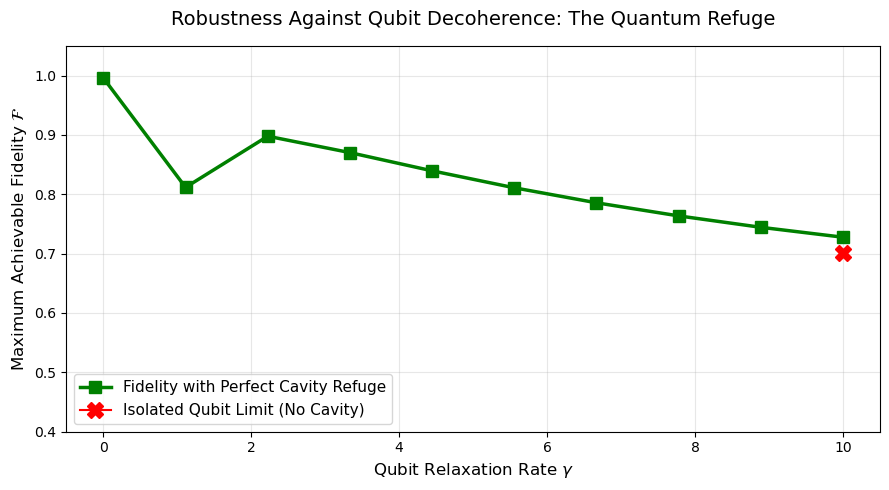

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import qutip_qoc as qoc
from qutip import liouvillian

# 1. Define the sweep array (10 points to save time for now!)
# We sweep kappa from 0.0 (perfect cavity) to 1.0 (very leaky cavity)
     

gamma_sweeps = np.linspace(0.0, 10.0, 10) # 10 points
best_fidelities_gamma = []

N_cav = 3
g_int = 0.3 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

# Base Operators
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))

# States
rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))
H_drift = g_int * (sm * a.dag() + sm.dag() * a) 
H_c = tensor(sigmay(), qeye(N_cav))             


kappa_fixed = 2.0 # The cavity is now a perfect, lossless refuge



print("🛡️ Starting Qubit Relaxation (Gamma) Sweep...")

current_guess = guess_params

for i, gamma_val in enumerate(gamma_sweeps):
    print(f"--- Optimizing Step {i+1}/10: gamma = {gamma_val:.2f} ---")
    
    # Rebuild collapse operators: Qubit has noise, Cavity is perfect
    c_ops_list = [np.sqrt(gamma_val) * sm, np.sqrt(kappa_fixed) * a]
    
    # Rebuild the Liouvillians
    L_drift = liouvillian(H_drift, c_ops_list)
    L_c = liouvillian(H_c) 
    
    H_model = [L_drift, [L_c, multi_gaussian_jax]]
    
    # Run JOPT
    result = qoc.optimize_pulses(
        objectives=qoc.Objective(rho0, H_model, rho_targ),
        control_parameters={
            "pulse_Y": {
                "guess": current_guess,
                "bounds": bounds,
            }
        },
        tlist=times,
        algorithm_kwargs={
            "alg": "JOPT",
            "fid_err_targ": 1e-3, 
            "max_iter": 500, 
        }
    )
    
    # Save fidelity
    fidelity = 1.0 - result.fid_err
    best_fidelities_gamma.append(fidelity)
    new_params = result.optimized_params[0]
    current_guess = new_params
    print(f"    Resulting Fidelity: {fidelity:.4f}\n")

print("✅ Gamma Sweep Complete! Generating graph...")

# ==========================================
# 4. PLOTTING THE REFUGE RESULTS
# ==========================================
plt.figure(figsize=(9, 5))

# Plot the new Gamma sweep
plt.plot(gamma_sweeps, best_fidelities_gamma, marker='s', markersize=8, color='#008000', linewidth=2.5, label='Fidelity with Perfect Cavity Refuge')

# Add the 0.70 markovian limit as a single point at gamma=10.0
# This makes the comparison perfectly scientifically accurate!
plt.plot(10.0, 0.7014, marker='X', markersize=12, color='red', label='Isolated Qubit Limit (No Cavity)')

# Styling
plt.title("Robustness Against Qubit Decoherence: The Quantum Refuge", fontsize=14, pad=15)
plt.xlabel(r"Qubit Relaxation Rate $\gamma$", fontsize=12)
plt.ylabel(r"Maximum Achievable Fidelity $\mathcal{F}$", fontsize=12)
plt.ylim(0.4, 1.05) 
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()

🔥 Starting 2D Heatmap Sweep...
Calculating row 1/10, col 1/10...
Calculating row 1/10, col 2/10...
Calculating row 1/10, col 3/10...
Calculating row 1/10, col 4/10...
Calculating row 1/10, col 5/10...
Calculating row 1/10, col 6/10...
Calculating row 1/10, col 7/10...
Calculating row 1/10, col 8/10...
Calculating row 1/10, col 9/10...
Calculating row 1/10, col 10/10...
Calculating row 2/10, col 1/10...
Calculating row 2/10, col 2/10...
Calculating row 2/10, col 3/10...
Calculating row 2/10, col 4/10...
Calculating row 2/10, col 5/10...
Calculating row 2/10, col 6/10...
Calculating row 2/10, col 7/10...
Calculating row 2/10, col 8/10...
Calculating row 2/10, col 9/10...
Calculating row 2/10, col 10/10...
Calculating row 3/10, col 1/10...
Calculating row 3/10, col 2/10...
Calculating row 3/10, col 3/10...
Calculating row 3/10, col 4/10...
Calculating row 3/10, col 5/10...
Calculating row 3/10, col 6/10...
Calculating row 3/10, col 7/10...
Calculating row 3/10, col 8/10...
Calculating row

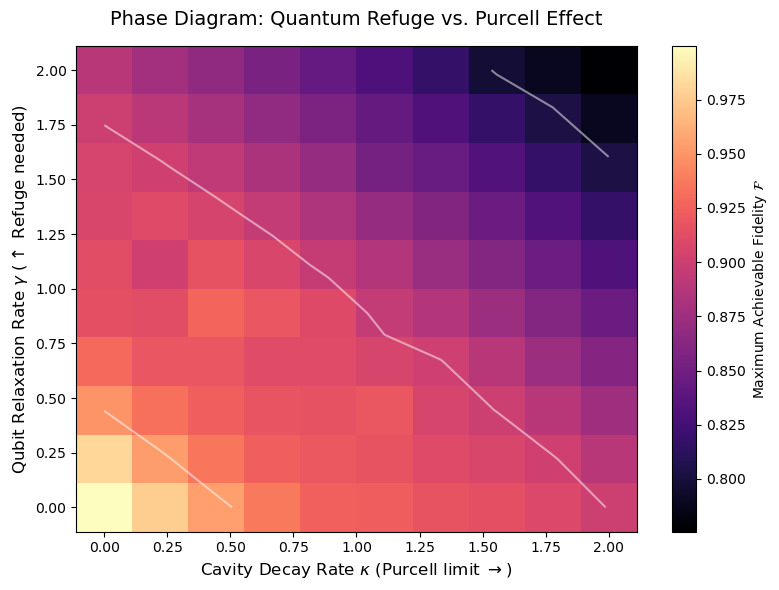

In [9]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, ket2dm, liouvillian
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

N_cav = 3
#g_int = 0.5 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

# Base Operators
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))

# States
rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

# Fixed coupling for the heatmap (e.g., strong coupling)
g_int_heatmap = 1.0 * 2 * np.pi
H_drift_heatmap = g_int_heatmap * (sm * a.dag() + sm.dag() * a)
H_c = tensor(sigmay(), qeye(N_cav))  
L_c = liouvillian(H_c)

@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3

guess_params = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
]


bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

# Define the 2D grid
grid_size = 10
gamma_vals = np.linspace(0.0, 2.0, grid_size)
kappa_vals = np.linspace(0.0, 2.0, grid_size)

# The matrix to store the results
fidelity_matrix = np.zeros((grid_size, grid_size))

print("🔥 Starting 2D Heatmap Sweep...")

for i, gamma in enumerate(gamma_vals):
    # Optional: Reset the guess at the start of each new gamma row
    
    for j, kappa in enumerate(kappa_vals):
        print(f"Calculating row {i+1}/{grid_size}, col {j+1}/{grid_size}...")
        
        # 1. Update BOTH noise channels
        c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa) * a]
        
        # 2. Rebuild the model
        L_drift = liouvillian(H_drift_heatmap, c_ops_list)
        H_model = [L_drift, [L_c, multi_gaussian_jax]]
        best_pixel_params = None
        
        result = qoc.optimize_pulses(
            objectives=qoc.Objective(rho0, H_model, rho_targ),
            control_parameters={"pulse_Y": {"guess": guess_params, "bounds": bounds}},
            tlist=times,
            algorithm_kwargs={"alg": "JOPT", "fid_err_targ": 1e-3, "max_iter": 50}
        )
            
        fid = 1.0 - result.fid_err
                
        # 1. Save the absolute best fidelity to the matrix
        fidelity_matrix[i, j] = fid
        

plt.figure(figsize=(8, 6))
# pcolormesh draws the 2D grid. cmap='magma' or 'viridis' look great for physics!
mesh = plt.pcolormesh(kappa_vals, gamma_vals, fidelity_matrix, shading='auto', cmap='magma')

plt.colorbar(mesh, label=r'Maximum Achievable Fidelity $\mathcal{F}$')
plt.title("Phase Diagram: Quantum Refuge vs. Purcell Effect", fontsize=14, pad=15)
plt.xlabel(r"Cavity Decay Rate $\kappa$ (Purcell limit $\rightarrow$)", fontsize=12)
plt.ylabel(r"Qubit Relaxation Rate $\gamma$ ($\uparrow$ Refuge needed)", fontsize=12)

# Optional: Add a contour line to show where fidelity drops below an acceptable threshold
plt.contour(kappa_vals, gamma_vals, fidelity_matrix, levels=[0.8, 0.9, 0.95], colors='white', alpha=0.5)

plt.tight_layout()
plt.savefig("kappa-sweeps_opti.pdf", format="pdf", bbox_inches="tight")
plt.show()

🚀 Starting Sweep for coupling g = 0.00...
--- Optimizing Step 1/10: kappa = 0.00 ---
    Resulting Fidelity: 0.9990

--- Optimizing Step 2/10: kappa = 0.56 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 3/10: kappa = 1.11 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 4/10: kappa = 1.67 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 5/10: kappa = 2.22 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 6/10: kappa = 2.78 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 7/10: kappa = 3.33 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 8/10: kappa = 3.89 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 9/10: kappa = 4.44 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 10/10: kappa = 5.00 ---
    Resulting Fidelity: 0.9991

🚀 Starting Sweep for coupling g = 2.51...
--- Optimizing Step 1/10: kappa = 0.00 ---
    Resulting Fidelity: 0.7385

--- Optimizing Step 2/10: kappa = 0.56 ---
    Resulting Fidelity: 0.6789

--- Optimizing 

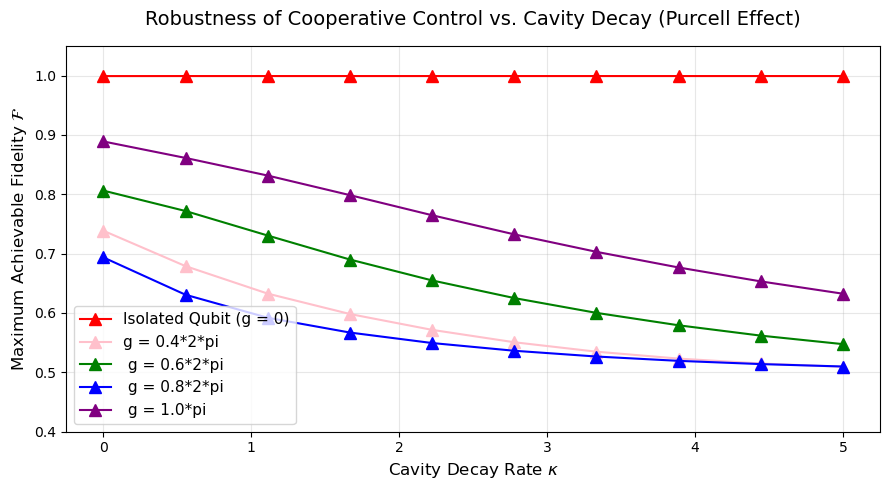

In [6]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, ket2dm, liouvillian
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

# ==========================================
# 1. SYSTEM PARAMETERS & OPERATORS
# ==========================================
N_cav = 3
#g_int = 0.5 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

gamma = 2.0  # Qubit relaxation kept at 0 so we only test Cavity decay

# Base Operators
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))

H_c = tensor(sigmay(), qeye(N_cav))             

# States
rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

# ==========================================
# 2. CONTROL PULSE (JAX) & BOUNDS
# ==========================================
@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3


bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

# ==========================================
# 3. THE KAPPA SWEEP (CAVITY DECAY)
# ==========================================
# We sweep kappa from 0.0 (perfect cavity) to 1.0 (very leaky cavity)
results_dict = {}

for g_int in [0.0, 0.4 * 2 * np.pi, 0.6 * 2 * np.pi, 0.8*2*np.pi, 1.0*2*np.pi]:
    H_drift = g_int * (sm * a.dag() + sm.dag() * a) 

    kappa_sweeps = np.linspace(0.0, 5.0, 10) # 10 points to run fast!
    current_g_fidelities = []

    current_guess = [2.0, T_total*0.25, 0.2, 
                     2.0, T_total * 0.50, 0.2,
                     2.0, T_total * 0.75, 0.2]

    print(f"🚀 Starting Sweep for coupling g = {g_int:.2f}...")

    for i, kappa_val in enumerate(kappa_sweeps):
        print(f"--- Optimizing Step {i+1}/10: kappa = {kappa_val:.2f} ---")
    
        # Rebuild collapse operators with the new kappa_val
        c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa_val) * a]
    
        # Rebuild the Liouvillians so the optimizer "sees" the new noise
        L_drift = liouvillian(H_drift, c_ops_list)
        L_c = liouvillian(H_c) 
    
        H_model = [L_drift, [L_c, multi_gaussian_jax]]
    
        # Run JOPT
        result = qoc.optimize_pulses(
            objectives=qoc.Objective(rho0, H_model, rho_targ),
            control_parameters={
                "pulse_Y": {
                    "guess": current_guess,
                    "bounds": bounds,
                }
            },
            tlist=times,
            algorithm_kwargs={
                "alg": "JOPT",
                "fid_err_targ": 1e-3, 
                "max_iter": 500, # Lower max_iter so the loop finishes in a few minutes
            }
        )
    
        # Save fidelity
        current_guess = result.optimized_params[0]
        fidelity = 1.0 - result.fid_err
        current_g_fidelities.append(fidelity)
        print(f"    Resulting Fidelity: {fidelity:.4f}\n")
    results_dict[g_int] = current_g_fidelities

print("✅ Sweep Complete! Generating graph...")

# ==========================================
# 4. PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(9, 5))
#plt.plot(kappa_sweeps, best_fidelities, marker='o', markersize=8, color='#800080', linewidth=2.5, label='Optimized Fidelity (JOPT)')

plt.plot(kappa_sweeps, results_dict[0.0], marker='^', markersize=8, color='red', label="Isolated Qubit (g = 0)")

# Plot the medium coupling
plt.plot(kappa_sweeps, results_dict[0.4 * 2 * np.pi], marker='^', markersize=8, color='pink', label="g = 0.4*2*pi")

# Plot the strong coupling
plt.plot(kappa_sweeps, results_dict[0.6 * 2 * np.pi], marker='^', markersize=8, color='green', label=" g = 0.6*2*pi")

plt.plot(kappa_sweeps, results_dict[0.8 * 2 * np.pi], marker='^', markersize=8, color='blue', label=" g = 0.8*2*pi")

plt.plot(kappa_sweeps, results_dict[1.0 * 2 * np.pi], marker='^', markersize=8, color='purple', label=" g = 1.0*pi")

# Styling
plt.title("Robustness of Cooperative Control vs. Cavity Decay (Purcell Effect)", fontsize=14, pad=15)
plt.xlabel(r"Cavity Decay Rate $\kappa$", fontsize=12)
plt.ylabel(r"Maximum Achievable Fidelity $\mathcal{F}$", fontsize=12)
plt.ylim(0.4, 1.05) 
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.savefig("kappa-sweeps_opti.pdf", format="pdf", bbox_inches="tight")
plt.show()

🚀  (gamma) Sweep...
--- Optimizing Step 1/10: gamma = 0.00 ---


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


    Resulting Fidelity: 0.9998

--- Optimizing Step 2/10: gamma = 0.56 ---
    Resulting Fidelity: 0.9985

--- Optimizing Step 3/10: gamma = 1.11 ---
    Resulting Fidelity: 0.9990

--- Optimizing Step 4/10: gamma = 1.67 ---
    Resulting Fidelity: 0.9991

--- Optimizing Step 5/10: gamma = 2.22 ---
    Resulting Fidelity: 0.9990

--- Optimizing Step 6/10: gamma = 2.78 ---
    Resulting Fidelity: 0.9990

--- Optimizing Step 7/10: gamma = 3.33 ---
    Resulting Fidelity: 0.9984

--- Optimizing Step 8/10: gamma = 3.89 ---
    Resulting Fidelity: 0.9977

--- Optimizing Step 9/10: gamma = 4.44 ---
    Resulting Fidelity: 0.9967

--- Optimizing Step 10/10: gamma = 5.00 ---
    Resulting Fidelity: 0.9953

🚀  (gamma) Sweep...
--- Optimizing Step 1/10: gamma = 0.00 ---
    Resulting Fidelity: 0.9973

--- Optimizing Step 2/10: gamma = 0.56 ---
    Resulting Fidelity: 0.9966

--- Optimizing Step 3/10: gamma = 1.11 ---
    Resulting Fidelity: 0.9956

--- Optimizing Step 4/10: gamma = 1.67 ---
    

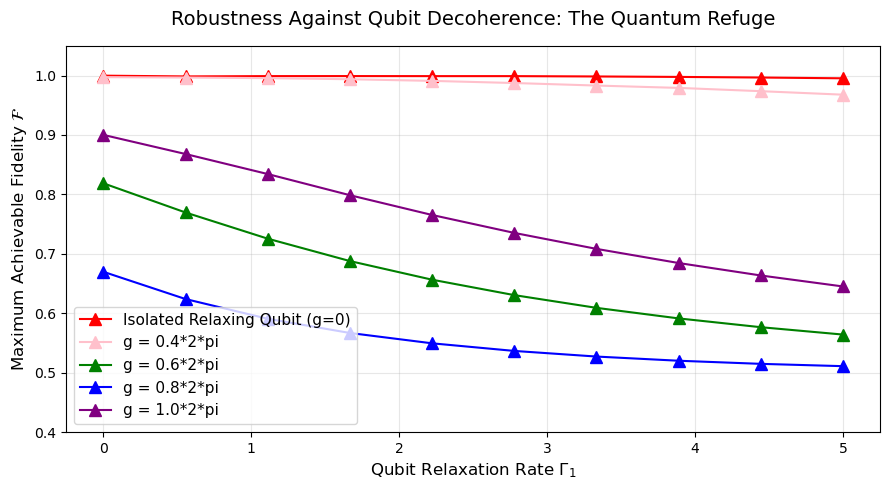

In [7]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, ket2dm, liouvillian
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

# ==========================================
# 1. SYSTEM PARAMETERS & OPERATORS
# ==========================================
N_cav = 3
#g_int = 0.5 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

kappa_val = 2.0  # Qubit relaxation kept at 0 so we only test Cavity decay

# Base Operators
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))

H_c = tensor(sigmay(), qeye(N_cav))             

# States
rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

# ==========================================
# 2. CONTROL PULSE (JAX) & BOUNDS
# ==========================================
@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3


bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

# ==========================================
# 3. THE KAPPA SWEEP (CAVITY DECAY)
# ==========================================
# We sweep kappa from 0.0 (perfect cavity) to 1.0 (very leaky cavity)
results_dict = {}

for g_int in [0.0, 0.4 * 2 * np.pi, 0.6*2*np.pi, 0.8*2*np.pi, 1.0 * 2 * np.pi]:
    H_drift = g_int * (sm * a.dag() + sm.dag() * a) 


    gamma_sweeps = np.linspace(0.0, 5.0, 10) # 10 points to run fast!
    current_g_fidelities = []
    current_guess = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
    ]

    print("🚀  (gamma) Sweep...")

    for i, gamma in enumerate(gamma_sweeps):
        print(f"--- Optimizing Step {i+1}/10: gamma = {gamma:.2f} ---")
    
        # Rebuild collapse operators with the new kappa_val
        c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa_val) * a]
    
        # Rebuild the Liouvillians so the optimizer "sees" the new noise
        L_drift = liouvillian(H_drift, c_ops_list)
        L_c = liouvillian(H_c) 
    
        H_model = [L_drift, [L_c, multi_gaussian_jax]]
    
        # Run JOPT
        result = qoc.optimize_pulses(
            objectives=qoc.Objective(rho0, H_model, rho_targ),
            control_parameters={
                "pulse_Y": {
                    "guess": current_guess,
                    "bounds": bounds,
                }
            },
            tlist=times,
            algorithm_kwargs={
                "alg": "JOPT",
                "fid_err_targ": 1e-3, 
                "max_iter": 500, # Lower max_iter so the loop finishes in a few minutes
            }
        )
    
        # Save fidelity
        current_guess = result.optimized_params[0]
        fidelity = 1.0 - result.fid_err
        current_g_fidelities.append(fidelity)
        print(f"    Resulting Fidelity: {fidelity:.4f}\n")
    results_dict[g_int] = current_g_fidelities

print("✅ Sweep Complete! Generating graph...")

# ==========================================
# 4. PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(9, 5))
#plt.plot(kappa_sweeps, best_fidelities, marker='o', markersize=8, color='#800080', linewidth=2.5, label='Optimized Fidelity (JOPT)')

plt.plot(gamma_sweeps, results_dict[0.0], color='red', marker='^', markersize=8, label="Isolated Relaxing Qubit (g=0)")
# Plot the medium coupling
plt.plot(gamma_sweeps, results_dict[0.4 * 2 * np.pi], marker='^', markersize=8, color='pink', label="g = 0.4*2*pi")

plt.plot(gamma_sweeps, results_dict[0.6 * 2 * np.pi], marker='^', markersize=8, color='green', label="g = 0.6*2*pi")

plt.plot(gamma_sweeps, results_dict[0.8 * 2 * np.pi], marker='^', markersize=8, color='blue', label="g = 0.8*2*pi")

plt.plot(gamma_sweeps, results_dict[1.0 * 2 * np.pi], marker='^', markersize=8, color='purple', label="g = 1.0*2*pi")

# Plot the strong coupling




# Add a horizontal line for the Markovian limit (approx 0.70 from your earlier tests)
#plt.axhline(0.70, color='red', linestyle='--', alpha=0.7, label='Markovian Limit (No Cavity Benefit)')

# Styling
plt.title("Robustness Against Qubit Decoherence: The Quantum Refuge", fontsize=14, pad=15)
plt.xlabel(r"Qubit Relaxation Rate $\Gamma_1$", fontsize=12)
plt.ylabel(r"Maximum Achievable Fidelity $\mathcal{F}$", fontsize=12)
plt.ylim(0.4, 1.05) 
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.savefig("gamma-sweeps_opti.pdf", format="pdf", bbox_inches="tight")
plt.show()

⏳ Starting Periodic Time Sweep (Quantum Choreography)...
--- Optimizing for gate time T = 0.50 s ---
--- Optimizing for gate time T = 0.74 s ---
--- Optimizing for gate time T = 0.97 s ---
--- Optimizing for gate time T = 1.21 s ---
--- Optimizing for gate time T = 1.45 s ---
--- Optimizing for gate time T = 1.68 s ---
--- Optimizing for gate time T = 1.92 s ---
--- Optimizing for gate time T = 2.16 s ---
--- Optimizing for gate time T = 2.39 s ---
--- Optimizing for gate time T = 2.63 s ---
--- Optimizing for gate time T = 2.87 s ---
--- Optimizing for gate time T = 3.11 s ---
--- Optimizing for gate time T = 3.34 s ---
--- Optimizing for gate time T = 3.58 s ---
--- Optimizing for gate time T = 3.82 s ---
--- Optimizing for gate time T = 4.05 s ---
--- Optimizing for gate time T = 4.29 s ---
--- Optimizing for gate time T = 4.53 s ---
--- Optimizing for gate time T = 4.76 s ---
--- Optimizing for gate time T = 5.00 s ---
✅ Time Sweep Complete!


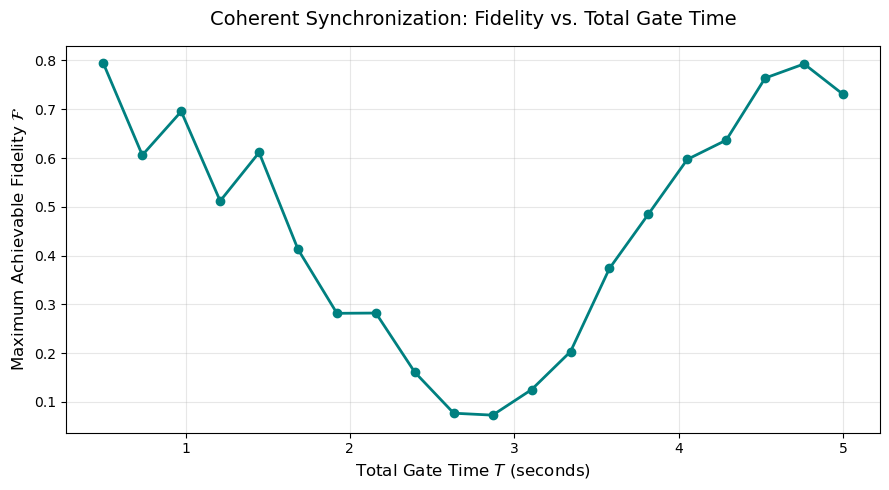

In [21]:
# 1. Sweep Parameters
# We test 20 different gate times between 0.5s and 5.0s
T_sweeps = np.linspace(0.5, 5.0, 20) 
fidelities_time_sweep = []

# Set strong coupling, but ZERO noise for this specific test 
# (We want to see the pure coherent exchange, not dissipation)
g_int_sweep = 2.0 * 2 * np.pi 
H_drift_sweep = g_int_sweep * (sm * a.dag() + sm.dag() * a)
c_ops_empty = [] # No gamma, no kappa

print("⏳ Starting Periodic Time Sweep (Quantum Choreography)...")

for T in T_sweeps:
    print(f"--- Optimizing for gate time T = {T:.2f} s ---")
    
    # 2. DYNAMICALLY scale the time array, guesses, and bounds for the current T
    times_T = np.linspace(0, T, 100)
    
    guess_T = [
        1.0, T * 0.25, T * 0.1,
        1.0, T * 0.50, T * 0.1,
        1.0, T * 0.75, T * 0.1
    ]
    
    # Keep the bounds tight (-1.0 to 1.0) so it is forced to use the cavity!
    bounds_T = [(-1.0, 1.0), (0.0, T), (0.01, T)] * 3 
    
    # 3. Rebuild the model
    L_drift_T = liouvillian(H_drift_sweep, c_ops_empty)
    H_model_T = [L_drift_T, [L_c, multi_gaussian_jax]]
    
    # 4. Run the optimizer
    result = qoc.optimize_pulses(
        objectives=qoc.Objective(rho0, H_model_T, rho_targ),
        control_parameters={"pulse_Y": {"guess": guess_T, "bounds": bounds_T}},
        tlist=times_T,
        algorithm_kwargs={"alg": "JOPT", "fid_err_targ": 1e-4, "max_iter": 300}
    )
    
    fidelity = 1.0 - result.fid_err
    fidelities_time_sweep.append(fidelity)

print("✅ Time Sweep Complete!")

# 5. Plot the Oscillations
plt.figure(figsize=(9, 5))
plt.plot(T_sweeps, fidelities_time_sweep, marker='o', markersize=6, color='teal', linewidth=2)

plt.title("Coherent Synchronization: Fidelity vs. Total Gate Time", fontsize=14, pad=15)
plt.xlabel(r"Total Gate Time $T$ (seconds)", fontsize=12)
plt.ylabel(r"Maximum Achievable Fidelity $\mathcal{F}$", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("time-sweeps_non-markov.pdf", format="pdf", bbox_inches="tight")
plt.show()

 Démarrage JOPT avec Liouvillian (Correction Décohérence)...
🧠 Lancement optimisation Liouvillian (Kappa=0.15, Gamma=0.0)...

✅ Terminé !
   -> Fidélité Finale (avec bruit) : 0.976319


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/core/data/expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


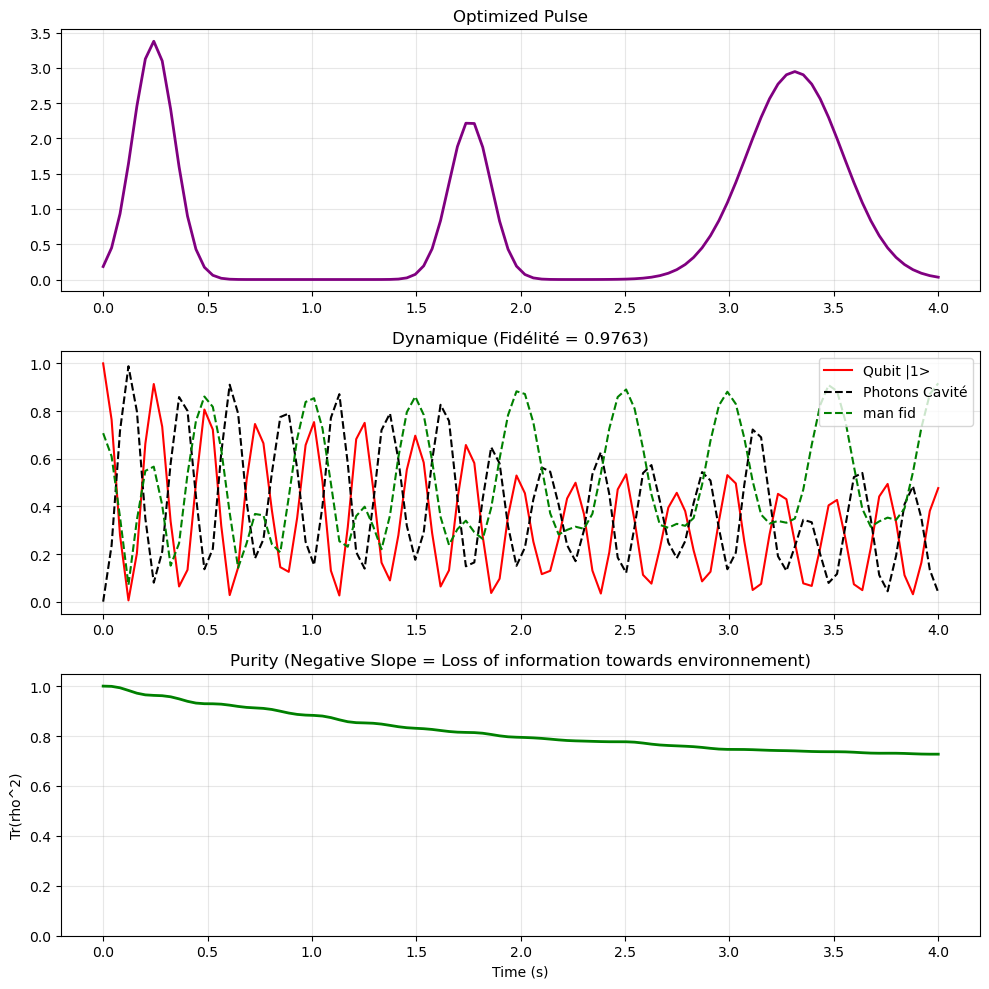

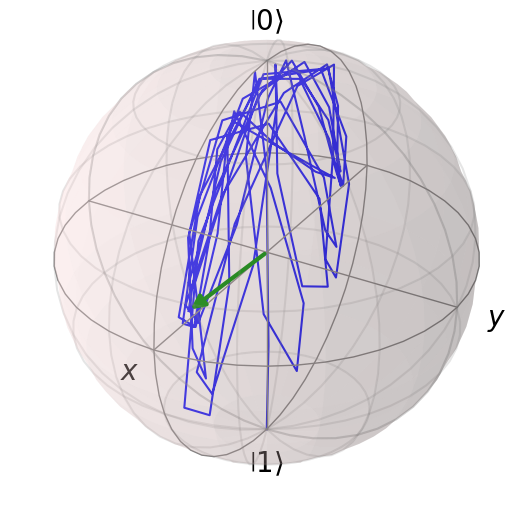

In [14]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, expect, ket2dm, liouvillian, mesolve
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

print(" Démarrage JOPT avec Liouvillian (Correction Décohérence)...")

# ==========================================
# 1. SYSTÈME PHYSIQUE & BRUIT
# ==========================================
N_cav = 3
g_int = 2.0 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

# Bruit
kappa = 0.15  # Fuite cavité
gamma = 0.00  # Relaxation qubit

# Opérateurs de base
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))
H_drift = g_int * (sm * a.dag() + sm.dag() * a) # Interaction
H_c = tensor(sigmay(), qeye(N_cav))             # Contrôle

# Opérateurs de collapse (Bruit)
c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa) * a]

# --- LA CORRECTION EST ICI : TRANSFORMATION EN LIOUVILLIAN ---
# On combine H_drift et c_ops dans une seule super-matrice L_drift
# L_drift contient TOUTE la dynamique naturelle (oscillations + mort)
L_drift = liouvillian(H_drift, c_ops_list)

# Le contrôle est aussi transformé en super-opérateur (sans bruit associé)
L_c = liouvillian(H_c) 

THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

# États (Matrices Densité obligatoires)
rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

# ==========================================
# 2. FONCTION JAX (9 Paramètres)
# ==========================================
@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3

# On définit le modèle avec les LIOUVILLIANS au lieu des Hamiltoniens
# Modèle = L_drift + u(t) * L_c
H_model = [L_drift, [L_c, multi_gaussian_jax]]

# ==========================================
# 3. OPTIMISATION
# ==========================================
guess_params = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
]
# On répète les bornes 3 fois pour les 9 paramètres
bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

print(f"🧠 Lancement optimisation Liouvillian (Kappa={kappa}, Gamma={gamma})...")

result = qoc.optimize_pulses(
    # On passe le modèle Liouvillian. Plus besoin de c_ops ici !
    objectives=qoc.Objective(rho0, H_model, rho_targ),
    
    control_parameters={
        "pulse_Y": {
            "guess": guess_params,
            "bounds": bounds,
        }
    },
    tlist=times,
    algorithm_kwargs={
        "alg": "JOPT",
        "fid_err_targ": 1e-3, # On vise 99.9% (difficile avec du bruit)
        "max_iter": 1000,
    }
)

# ==========================================
# 4. RÉSULTATS
# ==========================================
print("\n✅ Terminé !")
print(f"   -> Fidélité Finale (avec bruit) : {1 - result.fid_err:.6f}")

opt_params = result.optimized_params[0]

# Reconstruction Pulse (NumPy)
def multi_gaussian_numpy(t, p):
    return (p[0] * np.exp(-(t - p[1])**2 / (2 * p[2]**2)) +
            p[3] * np.exp(-(t - p[4])**2 / (2 * p[5]**2)) +
            p[6] * np.exp(-(t - p[7])**2 / (2 * p[8]**2)))

opt_pulse = multi_gaussian_numpy(times, opt_params)

# --- VÉRIFICATION ---
# Pour la simulation de vérification, on peut réutiliser mesolve standard
# C'est plus simple pour extraire les populations
H_final_sim = [H_drift, [H_c, opt_pulse]]
sim = qutip.mesolve(H_final_sim, rho0, times, c_ops=c_ops_list) # Ici on remet c_ops pour mesolve

# Pops
pop_qubit = expect(tensor(basis(2,1)*basis(2,1).dag(), qeye(N_cav)), sim.states)
pop_cav   = expect(tensor(qeye(2), destroy(N_cav).dag()*destroy(N_cav)), sim.states)
purity = [np.real((rho * rho).tr()) for rho in sim.states]
fid = [qutip.fidelity(rho, rho_targ) for rho in sim.states]

plt.figure(figsize=(10, 10))

# Pulse
plt.subplot(3, 1, 1)
plt.plot(times, opt_pulse, 'purple', lw=2)
plt.title("Optimized Pulse")
plt.grid(True, alpha=0.3)

# Dynamique
plt.subplot(3, 1, 2)
plt.plot(times, pop_qubit, 'r', label='Qubit |1>')
plt.plot(times, pop_cav, 'k--', label='Photons Cavité')
plt.plot(times, fid, 'g--', label='man fid')
plt.title(f"Dynamique (Fidélité = {1-result.fid_err:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)

# Pureté
plt.subplot(3, 1, 3)
plt.plot(times, purity, 'g', lw=2)
plt.title("Purity (Negative Slope = Loss of information towards environnement)")
plt.xlabel("Time (s)")
plt.ylabel("Tr(rho^2)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Fixed JOPT open system.pdf", format="pdf", bbox_inches="tight")
plt.show()


#BLOCH SPHERE
b = qutip.Bloch()

# 1. On extrait les états réduits du qubit
rho_qubit = [rho0.ptrace(0) for rho0 in sim.states]

# 2. On calcule les coordonnées géométriques (x, y, z) de la trajectoire
x = qutip.expect(qutip.sigmax(), rho_qubit)
y = qutip.expect(qutip.sigmay(), rho_qubit)
z = qutip.expect(qutip.sigmaz(), rho_qubit)

# 3. On ajoute ces coordonnées géométriques en tant que ligne continue (meth='l')
b.add_points([x, y, z], meth='l')

# 4. On isole le tout dernier état et on l'ajoute comme vecteur (flèche)
rho_final = sim.states[-1].ptrace(0)
b.add_states(rho_final, kind='vector')

# 5. On génère le graphique
b.show()

 Démarrage JOPT avec Liouvillian (Correction Décohérence)...
🧠 Lancement optimisation Liouvillian (Kappa=0.15, Gamma=0.0)...


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)



✅ Terminé !
   -> Fidélité Finale (avec bruit) : 0.983941


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/core/data/expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


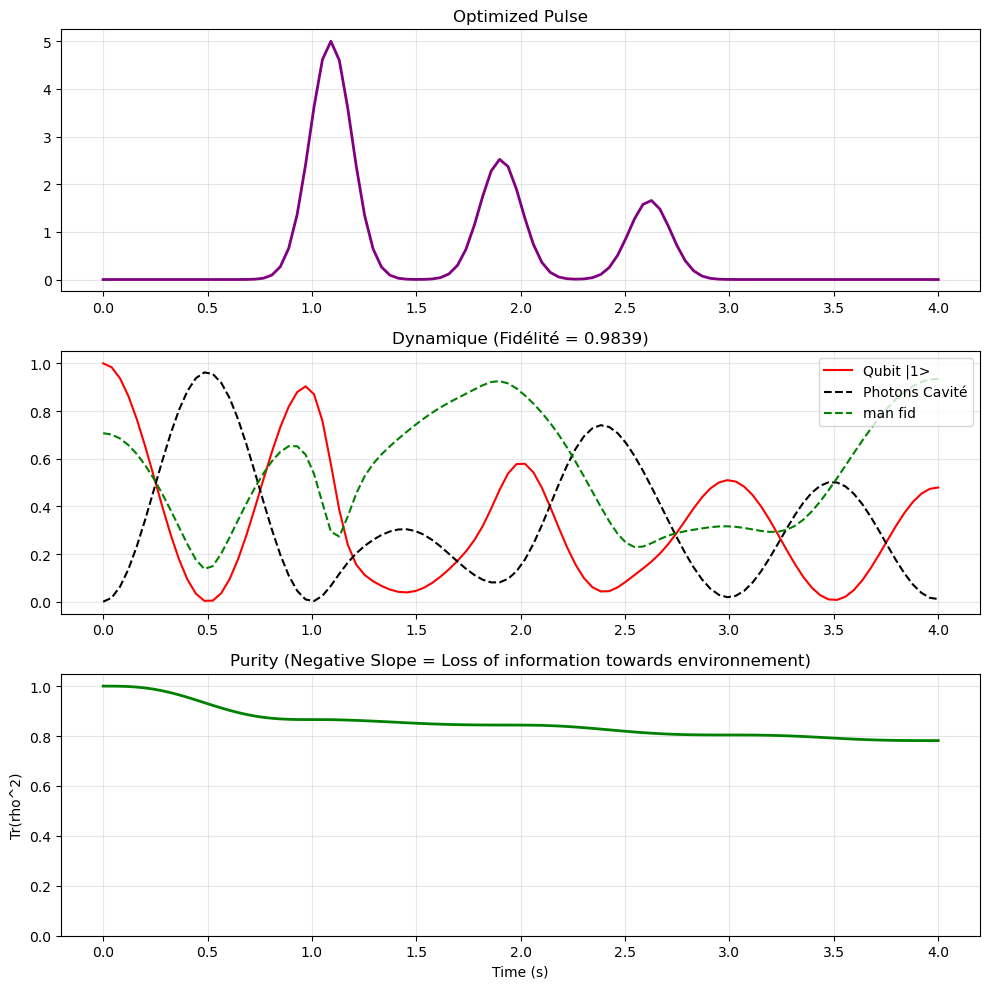

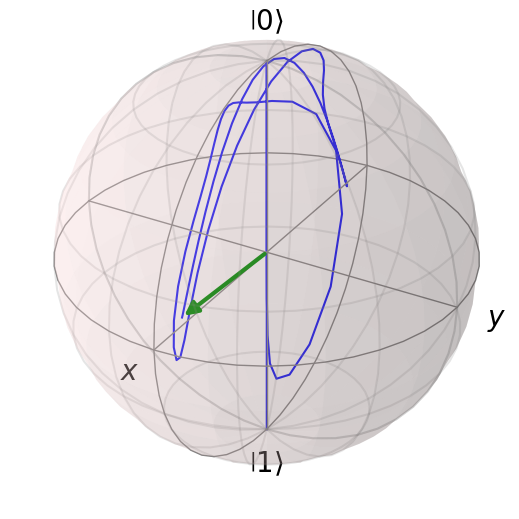

In [30]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, expect, ket2dm, liouvillian, mesolve
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

print(" Démarrage JOPT avec Liouvillian (Correction Décohérence)...")

# ==========================================
# 1. SYSTÈME PHYSIQUE & BRUIT
# ==========================================
N_cav = 3
g_int = 0.5 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

# Bruit
kappa = 0.15  # Fuite cavité
gamma = 0.00  # Relaxation qubit

# Opérateurs de base
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))
H_drift = g_int * (sm * a.dag() + sm.dag() * a) # Interaction
H_c = tensor(sigmay(), qeye(N_cav))             # Contrôle

# Opérateurs de collapse (Bruit)
c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa) * a]

# --- LA CORRECTION EST ICI : TRANSFORMATION EN LIOUVILLIAN ---
# On combine H_drift et c_ops dans une seule super-matrice L_drift
# L_drift contient TOUTE la dynamique naturelle (oscillations + mort)
L_drift = liouvillian(H_drift, c_ops_list)

# Le contrôle est aussi transformé en super-opérateur (sans bruit associé)
L_c = liouvillian(H_c) 

THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

# États (Matrices Densité obligatoires)
rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

# ==========================================
# 2. FONCTION JAX (9 Paramètres)
# ==========================================
@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3

# On définit le modèle avec les LIOUVILLIANS au lieu des Hamiltoniens
# Modèle = L_drift + u(t) * L_c
H_model = [L_drift, [L_c, multi_gaussian_jax]]

# ==========================================
# 3. OPTIMISATION
# ==========================================
guess_params = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
]
# On répète les bornes 3 fois pour les 9 paramètres
bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

print(f"🧠 Lancement optimisation Liouvillian (Kappa={kappa}, Gamma={gamma})...")

result = qoc.optimize_pulses(
    # On passe le modèle Liouvillian. Plus besoin de c_ops ici !
    objectives=qoc.Objective(rho0, H_model, rho_targ),
    
    control_parameters={
        "pulse_Y": {
            "guess": guess_params,
            "bounds": bounds,
        }
    },
    tlist=times,
    algorithm_kwargs={
        "alg": "JOPT",
        "fid_err_targ": 1e-3, # On vise 99.9% (difficile avec du bruit)
        "max_iter": 1000,
    }
)

# ==========================================
# 4. RÉSULTATS
# ==========================================
print("\n✅ Terminé !")
print(f"   -> Fidélité Finale (avec bruit) : {1 - result.fid_err:.6f}")

opt_params = result.optimized_params[0]

# Reconstruction Pulse (NumPy)
def multi_gaussian_numpy(t, p):
    return (p[0] * np.exp(-(t - p[1])**2 / (2 * p[2]**2)) +
            p[3] * np.exp(-(t - p[4])**2 / (2 * p[5]**2)) +
            p[6] * np.exp(-(t - p[7])**2 / (2 * p[8]**2)))

opt_pulse = multi_gaussian_numpy(times, opt_params)

# --- VÉRIFICATION ---
# Pour la simulation de vérification, on peut réutiliser mesolve standard
# C'est plus simple pour extraire les populations
H_final_sim = [H_drift, [H_c, opt_pulse]]
sim = qutip.mesolve(H_final_sim, rho0, times, c_ops=c_ops_list) # Ici on remet c_ops pour mesolve

# Pops
pop_qubit = expect(tensor(basis(2,1)*basis(2,1).dag(), qeye(N_cav)), sim.states)
pop_cav   = expect(tensor(qeye(2), destroy(N_cav).dag()*destroy(N_cav)), sim.states)
purity = [np.real((rho * rho).tr()) for rho in sim.states]
fid = [qutip.fidelity(rho, rho_targ) for rho in sim.states]

plt.figure(figsize=(10, 10))

# Pulse
plt.subplot(3, 1, 1)
plt.plot(times, opt_pulse, 'purple', lw=2)
plt.title("Optimized Pulse")
plt.grid(True, alpha=0.3)

# Dynamique
plt.subplot(3, 1, 2)
plt.plot(times, pop_qubit, 'r', label='Qubit |1>')
plt.plot(times, pop_cav, 'k--', label='Photons Cavité')
plt.plot(times, fid, 'g--', label='man fid')
plt.title(f"Dynamique (Fidélité = {1-result.fid_err:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)

# Pureté
plt.subplot(3, 1, 3)
plt.plot(times, purity, 'g', lw=2)
plt.title("Purity (Negative Slope = Loss of information towards environnement)")
plt.xlabel("Time (s)")
plt.ylabel("Tr(rho^2)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Fixed JOPT open system.pdf", format="pdf", bbox_inches="tight")
plt.show()


#BLOCH SPHERE
b = qutip.Bloch()

# 1. On extrait les états réduits du qubit
rho_qubit = [rho0.ptrace(0) for rho0 in sim.states]

# 2. On calcule les coordonnées géométriques (x, y, z) de la trajectoire
x = qutip.expect(qutip.sigmax(), rho_qubit)
y = qutip.expect(qutip.sigmay(), rho_qubit)
z = qutip.expect(qutip.sigmaz(), rho_qubit)

# 3. On ajoute ces coordonnées géométriques en tant que ligne continue (meth='l')
b.add_points([x, y, z], meth='l')

# 4. On isole le tout dernier état et on l'ajoute comme vecteur (flèche)
rho_final = sim.states[-1].ptrace(0)
b.add_states(rho_final, kind='vector')

# 5. On génère le graphique
b.show()

In [34]:
(qutip.ptrace(sim.states[-1],0)*qutip.ptrace(sim.states[-1],0)).tr()

0.790235470898919

 Démarrage JOPT avec Liouvillian (Correction Décohérence)...
🧠 Lancement optimisation Liouvillian (Kappa=0.15, Gamma=0.0)...

✅ Optimisation Terminée !
   -> Fidélité Finale visée : 0.983941
🔍 Calcul de la distance de trace (Mesure BLP)...


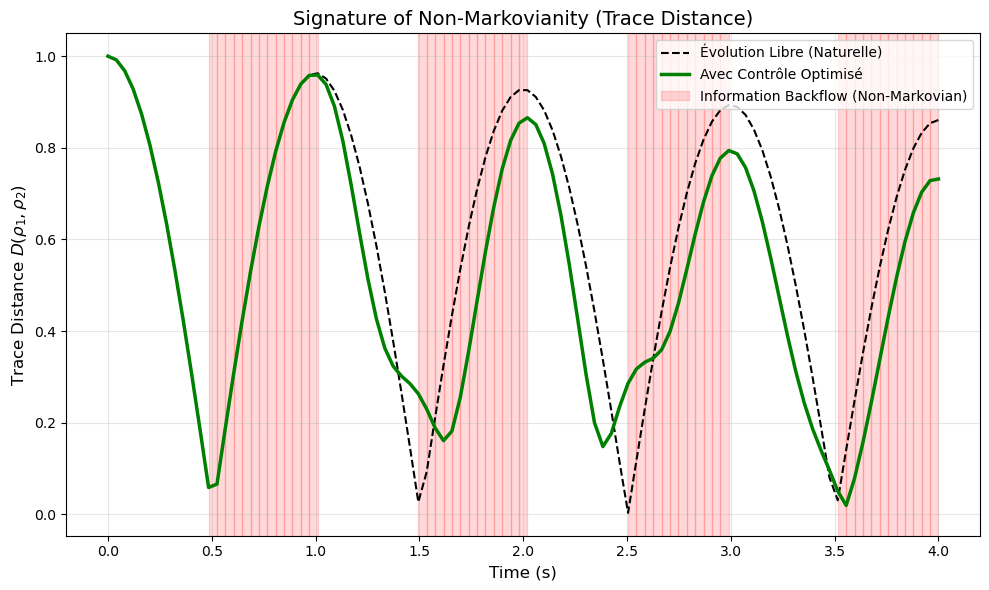

In [28]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, expect, ket2dm, liouvillian, mesolve
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

print(" Démarrage JOPT avec Liouvillian (Correction Décohérence)...")

# ==========================================
# 1. SYSTÈME PHYSIQUE & BRUIT
# ==========================================
N_cav = 3
g_int = 0.5 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

# Bruit
kappa = 0.15  # Fuite cavité
gamma = 0.00  # Relaxation qubit

# Opérateurs de base
a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))
H_drift = g_int * (sm * a.dag() + sm.dag() * a) # Interaction
H_c = tensor(sigmay(), qeye(N_cav))             # Contrôle

# Opérateurs de collapse (Bruit)
c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa) * a]

# --- LA CORRECTION EST ICI : TRANSFORMATION EN LIOUVILLIAN ---
# On combine H_drift et c_ops dans une seule super-matrice L_drift
# L_drift contient TOUTE la dynamique naturelle (oscillations + mort)
L_drift = liouvillian(H_drift, c_ops_list)

# Le contrôle est aussi transformé en super-opérateur (sans bruit associé)
L_c = liouvillian(H_c) 

THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

# États (Matrices Densité obligatoires)
rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

# ==========================================
# 2. FONCTION JAX (9 Paramètres)
# ==========================================
@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3

# On définit le modèle avec les LIOUVILLIANS au lieu des Hamiltoniens
# Modèle = L_drift + u(t) * L_c
H_model = [L_drift, [L_c, multi_gaussian_jax]]

# ==========================================
# 3. OPTIMISATION
# ==========================================
guess_params = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
]
# On répète les bornes 3 fois pour les 9 paramètres
bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

print(f"🧠 Lancement optimisation Liouvillian (Kappa={kappa}, Gamma={gamma})...")

result = qoc.optimize_pulses(
    # On passe le modèle Liouvillian. Plus besoin de c_ops ici !
    objectives=qoc.Objective(rho0, H_model, rho_targ),
    
    control_parameters={
        "pulse_Y": {
            "guess": guess_params,
            "bounds": bounds,
        }
    },
    tlist=times,
    algorithm_kwargs={
        "alg": "JOPT",
        "fid_err_targ": 1e-3, # On vise 99.9% (difficile avec du bruit)
        "max_iter": 1000,
    }
)

# ==========================================
# 4. RÉSULTATS
# ==========================================
# ==========================================
# 4. MESURE DE LA NON-MARKOVIANITÉ (BLP)
# ==========================================
print("\n✅ Optimisation Terminée !")
print(f"   -> Fidélité Finale visée : {1 - result.fid_err:.6f}")

# 1. On extrait les 9 paramètres magiques trouvés par JOPT
opt_params = result.optimized_params[0]

# 2. Reconstruction du pulse en format classique (NumPy) pour la simulation
def multi_gaussian_numpy(t, p):
    return (p[0] * np.exp(-(t - p[1])**2 / (2 * p[2]**2)) +
            p[3] * np.exp(-(t - p[4])**2 / (2 * p[5]**2)) +
            p[6] * np.exp(-(t - p[7])**2 / (2 * p[8]**2)))

# 3. La fonction BLP adaptée pour s'intégrer à tes variables globales
def measure_blp(params=None):
    # Etats initiaux orthogonaux sur l'équateur
    psi1 = tensor((basis(2,0) + basis(2,1)).unit(), basis(N_cav, 0))
    psi2 = tensor((basis(2,0) - basis(2,1)).unit(), basis(N_cav, 0))

    if params is not None:
        pulse_vals = multi_gaussian_numpy(times, params)
        H_sim = [H_drift, [H_c, pulse_vals]]
        label = "Avec Contrôle Optimisé"
    else:
        H_sim = H_drift
        label = "Évolution Libre (Naturelle)"

    # ATTENTION : On utilise mesolve avec H_drift et c_ops (et non L_drift !)
    sim1 = mesolve(H_sim, psi1, times, c_ops=c_ops_list)
    sim2 = mesolve(H_sim, psi2, times, c_ops=c_ops_list)

    trace_dist = []
    for r1, r2 in zip(sim1.states, sim2.states):
        # Trace partielle sur la cavité (on garde l'index 0 = qubit)
        rho1_q = r1.ptrace(0)
        rho2_q = r2.ptrace(0)
        trace_dist.append(qutip.tracedist(rho1_q, rho2_q))

    return times, np.array(trace_dist), label

# --- EXECUTION ET AFFICHAGE ---
print("🔍 Calcul de la distance de trace (Mesure BLP)...")
t, dist_free, lab_free = measure_blp(params=None)
t, dist_opt, lab_opt  = measure_blp(params=opt_params)

# --- LE GRAPHE ---
plt.figure(figsize=(10, 6))
plt.plot(t, dist_free, 'k--', label=lab_free)
plt.plot(t, dist_opt, '#008000', lw=2.5, label=lab_opt)

# Colorier les zones de "Backflow" pour l'évolution libre
added_label = False
diff = np.diff(dist_free)
for i, d in enumerate(diff):
    if d > 0: # Si la dérivée est positive = L'information revient !
        if not added_label:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15, label='Information Backflow (Non-Markovian)')
            added_label = True
        else:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15)

plt.title("Signature of Non-Markovianity (Trace Distance)", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel(r"Trace Distance $D(\rho_1, \rho_2)$", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Signature of Non-Markovianity (Trace Distance).pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:

plt.figure(figsize=(10, 10))

# Pulse
plt.subplot(3, 1, 1)
plt.plot(times, opt_pulse, 'purple', lw=2)
plt.title("Pulse Optimisé (Compense la Dissipation)")
plt.grid(True, alpha=0.3)

# Dynamique
plt.subplot(3, 1, 2)
plt.plot(times, pop_qubit, 'r', label='Qubit |1>')
plt.plot(times, pop_cav, 'k--', label='Photons Cavité')
plt.title(f"Dynamique (Fidélité = {1-result.fid_err:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)

# Pureté
plt.subplot(3, 1, 3)
plt.plot(times, purity, 'g', lw=2)
plt.title("Pureté (Baisse = Perte d'information vers l'environnement)")
plt.xlabel("Temps (s)")
plt.ylabel("Tr(rho^2)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
def measure_non_markovianity(T_total, n_slices, g_val, pulse_params=None):

    """

    Mesure la Non-Markovianité via la distance de trace entre deux états initiaux orthogonaux.

    Si pulse_params est None, on mesure le système libre (sans laser).

    Si pulse_params est donné, on mesure sous contrôle.

    """

    tlist = np.linspace(0, T_total, n_slices)

    

    # --- 1. Définir deux états initiaux orthogonaux pour le Qubit ---

    # Etat 1 : |+> = (|0> + |1>) / sqrt(2)

    psi1_q = (basis(2,0) + basis(2,1)).unit()

    # Etat 2 : |-> = (|0> - |1>) / sqrt(2)

    psi1_m = (basis(2,0) - basis(2,1)).unit()

    

    # La cavité est vide au départ pour les deux cas

    psi_cav = basis(N_cav, 0)

    

    psi1 = tensor(psi1_q, psi_cav)

    psi2 = tensor(psi1_m, psi_cav)

    

    # --- 2. Définir l'Hamiltonien ---

    # On reconstruit l'Hamiltonien QuTiP (H_int + H_control)

    a_q  = tensor(qeye(2), destroy(N_cav))

    sm_q = tensor(destroy(2), qeye(N_cav))

    sy_q = tensor(sigmay(), qeye(N_cav))

    

    H_int = g_val * (sm_q * a_q.dag() + sm_q.dag() * a_q)

    

    if pulse_params is not None:

        # On recrée le pulse optimisé

        # Attention : pulse_func doit être accessible ou redéfinie ici

        # On suppose que tu as gardé la fonction 'pulse_func' du bloc précédent

        pulse_vals = np.array([pulse_func(t, pulse_params) for t in tlist], dtype=float)

        H_total = [H_int, [sy_q, pulse_vals]]

        label = "Avec Contrôle Optimisé"

    else:

        H_total = H_int

        label = "Libre (Sans Laser)"

        

    # --- 3. Evolution ---

    # On fait évoluer les DEUX états

    sim1 = mesolve(H_total, psi1, tlist, [], [])

    sim2 = mesolve(H_total, psi2, tlist, [], [])

    

    # --- 4. Calcul de la Distance de Trace ---

    trace_dist = []

    for rho1, rho2 in zip(sim1.states, sim2.states):

        # On prend la trace partielle sur la cavité (on regarde l'info dans le Qubit)

        rho1_q = rho1.ptrace(0)

        rho2_q = rho2.ptrace(0)

        # Calcul de la distance

        d = qutip.tracedist(rho1_q, rho2_q)

        trace_dist.append(d)

        

    return tlist, np.array(trace_dist), label



# --- UTILISATION ---



# 1. Mesure SANS laser (Pour voir la mémoire naturelle du système)

t, dist_free, lab_free = measure_non_markovianity(T_total, 100, g_int, pulse_params=None)



# 2. Mesure AVEC ton résultat optimisé (res.x vient de ton code précédent)

t, dist_opt, lab_opt = measure_non_markovianity(T_total, 100, g_int, pulse_params=res.x)



# --- GRAPHIQUE ---

plt.figure(figsize=(10, 6))

plt.plot(t, dist_free, 'k--', label=f"{lab_free} (Naturel)")

plt.plot(t, dist_opt, 'g-', lw=2, label=f"{lab_opt}")



# Zone de Non-Markovianité (Quand la pente est positive)

diff = np.diff(dist_free)

for i, d in enumerate(diff):

    if d > 0:

        plt.axvspan(t[i], t[i+1], color='red', alpha=0.1)



plt.title("Signature de la Non-Markovianité (Distance de Trace)")

plt.xlabel("Temps (s)")

plt.ylabel("Distinguabilité des états (D)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

# --- GRAPHIQUE AMÉLIORÉ ---
plt.figure(figsize=(10, 6))
plt.plot(t, dist_free, 'k--', label=f"{lab_free} (Naturel)")
plt.plot(t, dist_opt, 'g-', lw=2, label=f"{lab_opt}")

# On crée un "flag" pour n'ajouter le label de la zone rouge qu'une seule fois
added_label = False
diff = np.diff(dist_free)
for i, d in enumerate(diff):
    if d > 0:
        if not added_label:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15, label='Information Backflow (Non-Markovian)')
            added_label = True
        else:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15)

plt.title("Signature of Non-Markovianity via Trace Distance", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel(r"Trace Distance $D(\rho_1, \rho_2)$", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


NameError: name 'res' is not defined